In [ ]:
%pip install gpt4all
%pip install torch
%pip install llama-cpp-python --upgrade
%pip install tqdm
%pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 115.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninst

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

%cd '/content/drive/MyDrive/'

Mounted at /content/drive
/content/drive/MyDrive


In [ ]:
!pip uninstall -y pandas numpy torch
!pip install pandas numpy torch

Found existing installation: pandas 2.2.3
Uninstalling pandas-2.2.3:
  Successfully uninstalled pandas-2.2.3
Found existing installation: numpy 2.2.5
Uninstalling numpy-2.2.5:
  Successfully uninstalled numpy-2.2.5
Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
  Using cached pandas-2.2.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (89 kB)
  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached pandas-2.2.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.1 MB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from gpt4all import GPT4All
from llama_cpp import Llama
import torch
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util

In [ ]:
class_labels = ["donation_and_volunteering", "requests_or_needs", "sympathy_and_support", "infrastructure_and_utilities_damage",
                "affected_individual", "caution_and_advice", "injured_or_dead_people", "response_efforts", "missing_and_found_people", "displaced_and_evacuations", "not_humanitarian"]

In [ ]:
model = Llama(model_path="/content/drive/MyDrive/mistral-7b-openorca.gguf2.Q4_0.gguf",
              n_gpu_layers=100,
              n_ctx=2048,
              n_threads=8)

llama_model_loader: loaded meta data with 22 key-value pairs and 291 tensors from /content/drive/MyDrive/mistral-7b-openorca.gguf2.Q4_0.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = Open-Orca_Mistral-7B-OpenOrca
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loader: - kv   6:                 llama.rope.dimension_count u32              = 128
llama_model_loader: - kv   7: 

In [ ]:
!nvidia-smi

Sat Apr 26 16:26:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             41W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/LLM_testing_sample.tsv', sep='\t')
new_df = df[["text", "informativeness_label", "humanitarian_label"]]

In [ ]:
def gen_labels(text, labels):
  embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
  text_embedding = embedding_model.encode(text, convert_to_tensor=True)
  label_embeddings = embedding_model.encode(labels, convert_to_tensor=True)

  cosine_sim = util.cos_sim(text_embedding, label_embeddings)
  hard_label = labels[torch.argmax(cosine_sim, dim=1).item()]

  soft_label = torch.nn.functional.softmax(torch.tensor(cosine_sim), dim=-1).tolist()
  return hard_label, soft_label, cosine_sim

In [ ]:
def get_targets(model, df):
    df['predicted_hard_class_label'] = ""
    df['predicted_soft_class_label'] = ""
    df['model_response'] = ""
    df['similarity_scores'] = ""

    for i, ind in tqdm(df.iterrows(), total=len(df)):
        message = ind["text"]

        class_prompt = f"""
        You are a humanitarian tweet classification expert.

        Given a tweet, first determine whether it is informative or not.
        If the tweet is **not informative**, return: "not_humanitarian".
        A tweet that is considered informative is a tweet that discusses any aid, support, or efforts to help those affected by a humanitarian crisis or discussion about an ongoing humanitarian crisis.
        If it is **informative**, classify it into one of the following categories:


        - donation_and_volunteering
        - requests_or_needs
        - sympathy_and_support
        - infrastructure_and_utilities_damage
        - affected_individual
        - caution_and_advice
        - injured_or_dead_people
        - response_efforts
        - missing_and_found_people
        - displaced_and_evacuations

        Respond with the final label: one of the above, or "not_humanitarian".

        Here is some examples on how I want you to classify tweets:
        Example 1:

        Tweet:
        Help victims of Maring. Pls donate to the Red Cross. GLOBE subs, please text RED &lt;5,25,50,100 or 300&gt; to 2899 #rescuePH
        Answer:
        "donation_and_volunteering"


        Example 2:
        Tweet:
        Half of me wants to tell you the other half says no,Confusion is running though my mind,I Just wish you had the answers,&amp; not just my heart
        Answer:
        "not_humanitarian"


        Example 3:
        Tweet:
        VIDEO: 'I survived by eating butter': A 15-year-old boy rescued from the rubble of Nepal's earthquake, says he‰Û_ http://t.co/YMtsFihvnp
        Answer:
        "missing_and_found_people"

        Tweet: {message}"""

        class_response = model(class_prompt, max_tokens=150)
        class_model_response = class_response['choices'][0]['text'].strip().title()
        class_hard, class_soft, cosine_sim = gen_labels(class_model_response, class_labels)
        df.at[i, 'predicted_hard_class_label'] = class_hard
        df.at[i, 'predicted_soft_class_label'] = class_soft
        df.at[i, 'similarity_scores'] = cosine_sim.tolist()
        df.at[i, 'model_response'] = class_model_response

    return df



In [ ]:
output_df = get_targets(model, new_df)

<ipython-input-8-b03a14fe9116>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted_hard_class_label'] = ""
<ipython-input-8-b03a14fe9116>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted_soft_class_label'] = ""
<ipython-input-8-b03a14fe9116>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Streaming output truncated to the last 5000 lines.
llama_perf_context_print: prompt eval time =     821.81 ms /    19 tokens (   43.25 ms per token,    23.12 tokens per second)
llama_perf_context_print:        eval time =    1463.51 ms /    12 runs   (  121.96 ms per token,     8.20 tokens per second)
llama_perf_context_print:       total time =    2292.13 ms /    31 tokens
 20%|██        | 251/1250 [40:02<2:59:06, 10.76s/it]Llama.generate: 487 prefix-match hit, remaining 75 prompt tokens to eval
llama_perf_context_print:        load time =   19579.81 ms
llama_perf_context_print: prompt eval time =    2614.17 ms /    75 tokens (   34.86 ms per token,    28.69 tokens per second)
llama_perf_context_print:        eval time =    2455.66 ms /    20 runs   (  122.78 ms per token,     8.14 tokens per second)
llama_perf_context_print:       total time =    5080.32 ms /    95 tokens
 20%|██        | 252/1250 [40:09<2:43:37,  9.84s/it]Llama.generate: 487 prefix-match hit, remaining 33 prompt tok

In [ ]:
output_df.to_json("crisis_label_output.json")

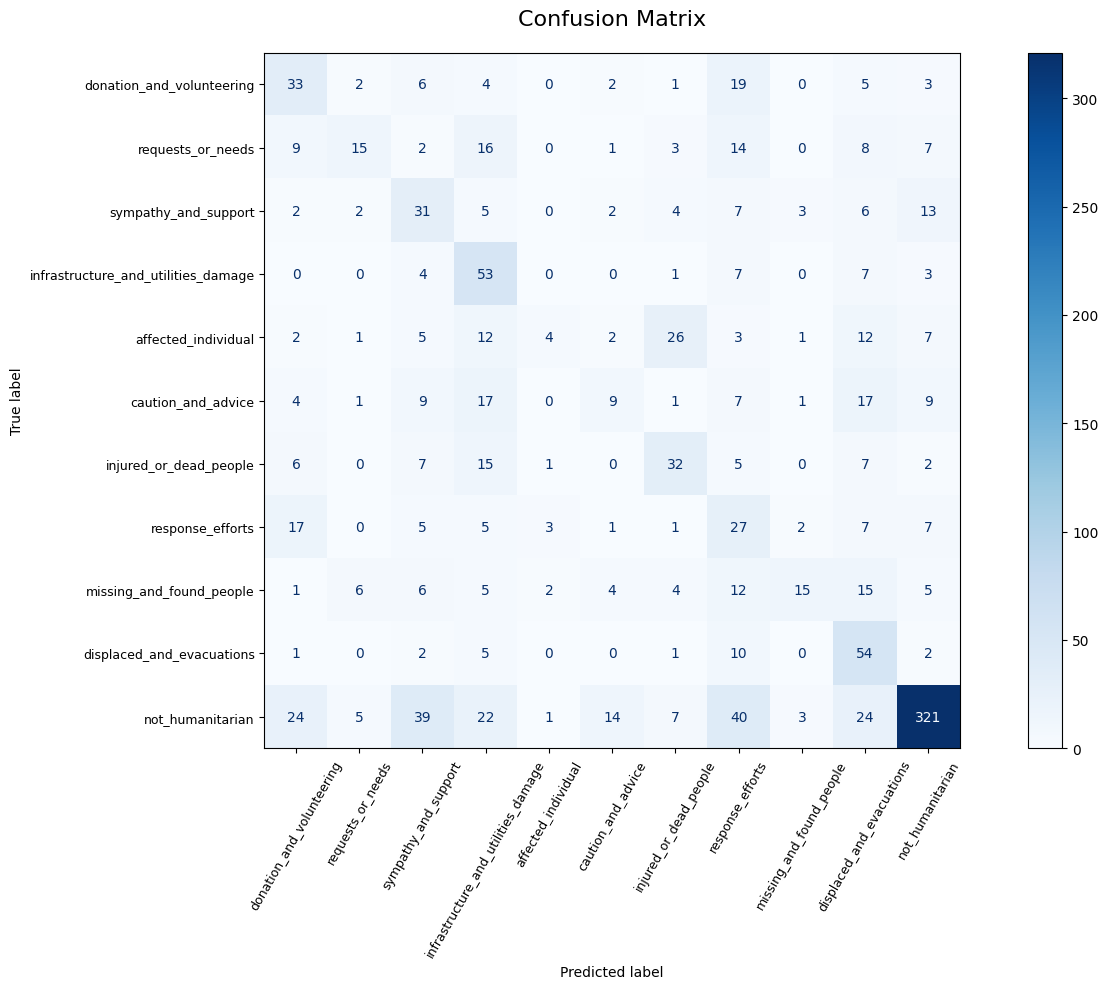

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = output_df["humanitarian_label"]
y_pred = output_df["predicted_hard_class_label"]

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=class_labels)

# Plot it
fig, ax = plt.subplots(figsize=(14, 10))  # Wider for long class names
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

disp.plot(
    ax=ax,
    cmap='Blues',
    xticks_rotation=60,   # More angle = more space
    values_format='d'
)

plt.title("Confusion Matrix", fontsize=16, pad=20)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.subplots_adjust(bottom=0.25)  # Shift plot up to fit labels
plt.grid(False)
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(output_df["humanitarian_label"], output_df["predicted_hard_class_label"])
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 47.52%


In [ ]:
cleaned_df = output_df[output_df["humanitarian_label"] == output_df["predicted_hard_class_label"]].reset_index(drop=True)

In [ ]:
cleaned_df.to_json("cleaned_crisis_label_output.json", orient="records", lines=True)